# XRD-CT inspection

This version never loads the full `recon` volume into RAM.

It:
1. reads only the 2θ axis and dataset shape;
2. computes the total-intensity map in chunks;
3. reads only one pixel or selected ROI for the pattern viewer;
4. computes phase maps directly from the HDF5 dataset in chunks;
5. supports raw ROI intensity or net intensity after subtraction of a linear background between the ROI endpoints.


In [1]:
# CELL 1 — Imports and file configuration

%matplotlib widget

from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from matplotlib.colors import LogNorm, Normalize
from matplotlib.widgets import RectangleSelector
from matplotlib.patches import Rectangle

from ipywidgets import (
    FloatRangeSlider, Checkbox, Text, VBox, HBox, Button,
    HTML, Layout, ToggleButtons, Dropdown
)
from IPython.display import display

plt.close("all")

folder_path = Path("/home/esrf/tran/Van tomo")
scan_path = folder_path / "pap_96m2_top1928_xrdct_recon.h5"

recon_path = "/recon"
twotheta_path = "/tth"

# Number of 2θ frames read at once.
# Reduce this if RAM is still limited.
THETA_CHUNK = 16


In [2]:
# CELL 2 — Inspect file and load only metadata + 2θ axis

with h5py.File(scan_path, "r") as f:
    x = f[twotheta_path][:].astype(np.float64, copy=False)
    recon_shape = f[recon_path].shape
    recon_dtype = f[recon_path].dtype

n_theta, n_rows, n_cols = recon_shape

assert n_theta == len(x), "The first recon dimension must match the 2θ axis."
assert np.all(np.diff(x) > 0), "The 2θ axis must be strictly increasing."

print("File:", scan_path)
print("2θ points:", n_theta)
print("Map size:", n_rows, "x", n_cols)
print("Stored dtype:", recon_dtype)
print("Full recon is not loaded into RAM.")


File: /home/esrf/tran/Van tomo/pap_96m2_top1928_xrdct_recon.h5
2θ points: 1500
Map size: 893 x 893
Stored dtype: float32
Full recon is not loaded into RAM.


In [3]:
# CELL 3 — Chunked total-intensity map

total_intensity_map = np.zeros((n_rows, n_cols), dtype=np.float32)

with h5py.File(scan_path, "r") as f:
    dset = f[recon_path]

    for start in range(0, n_theta, THETA_CHUNK):
        stop = min(start + THETA_CHUNK, n_theta)

        # Accumulate in float32 to limit memory use.
        block_sum = np.sum(
            dset[start:stop, :, :],
            axis=0,
            dtype=np.float32,
        )
        total_intensity_map += block_sum

positive = total_intensity_map[total_intensity_map > 0]

if positive.size:
    norm = LogNorm(
        vmin=np.percentile(positive, 1),
        vmax=np.percentile(positive, 99.9),
    )
else:
    norm = Normalize(
        vmin=float(total_intensity_map.min()),
        vmax=float(total_intensity_map.max()),
    )

print(f"Total-map RAM: {total_intensity_map.nbytes / 1e6:.1f} MB")


Total-map RAM: 3.2 MB


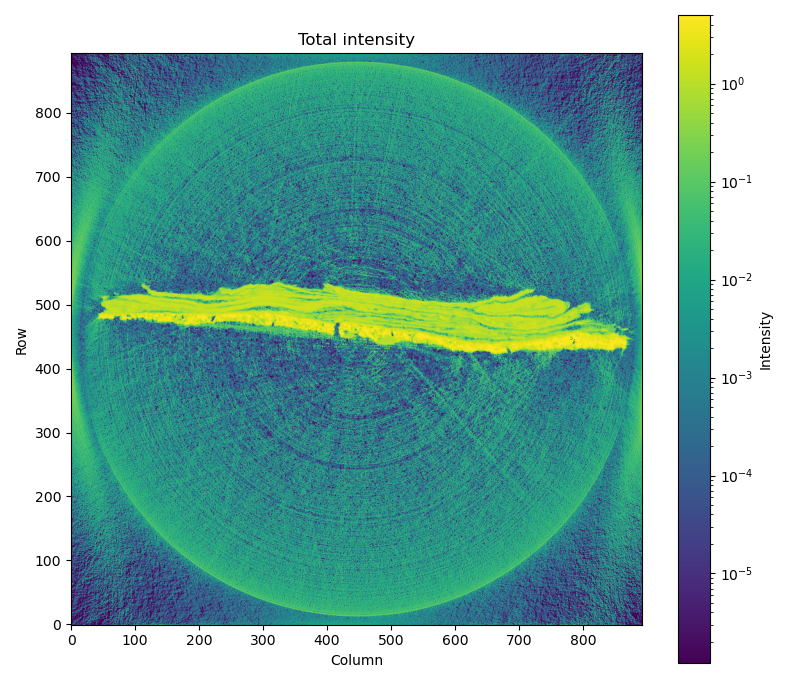

In [4]:
# CELL 4 — Display total-intensity map

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    total_intensity_map,
    norm=norm,
    cmap="viridis",
    origin="lower",
    aspect="equal",
)

ax.set_title("Total intensity")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
fig.colorbar(im, ax=ax, label="Intensity")
fig.tight_layout()


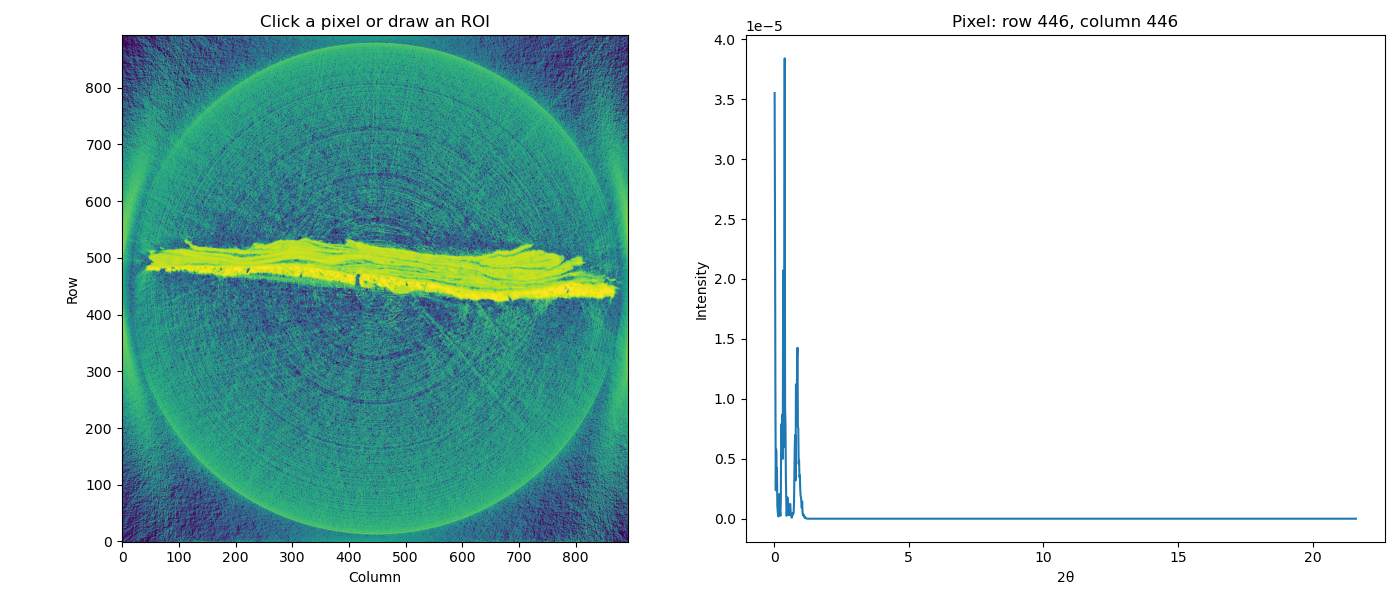

In [10]:
# CELL 5 — Efficient pixel / rectangular-ROI pattern viewer

plt.close("all")

mode_toggle = ToggleButtons(
    options=["Click pixel", "Draw ROI"],
    description="Mode:",
)

logy_checkbox = Checkbox(
    value=False,
    description="Log y-scale",
)

roi_mode_dropdown = Dropdown(
    options=["mean", "sum"],
    value="mean",
    description="ROI:",
)

fig2, (ax_map, ax_pat) = plt.subplots(1, 2, figsize=(14, 6))

ax_map.imshow(
    total_intensity_map,
    norm=norm,
    cmap="viridis",
    origin="lower",
    aspect="equal",
)
ax_map.set_title("Click a pixel or draw an ROI")
ax_map.set_xlabel("Column")
ax_map.set_ylabel("Row")

roi_patch = Rectangle(
    (0, 0), 0, 0,
    fill=False,
    edgecolor="red",
    linewidth=1.5,
)
ax_map.add_patch(roi_patch)
roi_patch.set_visible(False)

r_init = n_rows // 2
c_init = n_cols // 2

with h5py.File(scan_path, "r") as f:
    pattern0 = f[recon_path][:, r_init, c_init]

line, = ax_pat.plot(x, pattern0)
ax_pat.set_xlabel("2θ")
ax_pat.set_ylabel("Intensity")
ax_pat.set_title(f"Pixel: row {r_init}, column {c_init}")

state = {"bounds": (r_init, r_init, c_init, c_init)}


def read_roi_pattern(r0, r1, c0, c1, mode):
    """Read one spatial ROI without loading the full recon volume."""

    pattern = np.zeros(n_theta, dtype=np.float64)
    npix = (r1 - r0 + 1) * (c1 - c0 + 1)

    with h5py.File(scan_path, "r") as f:
        dset = f[recon_path]

        for start in range(0, n_theta, THETA_CHUNK):
            stop = min(start + THETA_CHUNK, n_theta)
            block = dset[start:stop, r0:r1 + 1, c0:c1 + 1]

            pattern[start:stop] = np.sum(
                block,
                axis=(1, 2),
                dtype=np.float64,
            )

    if mode == "mean":
        pattern /= npix

    return pattern


def update_pattern(r0, r1, c0, c1):
    state["bounds"] = (r0, r1, c0, c1)

    is_pixel = (r0 == r1) and (c0 == c1)

    if is_pixel:
        with h5py.File(scan_path, "r") as f:
            pattern = f[recon_path][:, r0, c0]
        title = f"Pixel: row {r0}, column {c0}"
    else:
        mode = roi_mode_dropdown.value
        pattern = read_roi_pattern(r0, r1, c0, c1, mode)
        npix = (r1 - r0 + 1) * (c1 - c0 + 1)
        title = (
            f"ROI {mode}: rows {r0}–{r1}, "
            f"columns {c0}–{c1} ({npix} pixels)"
        )

    roi_patch.set_bounds(
        c0 - 0.5,
        r0 - 0.5,
        c1 - c0 + 1,
        r1 - r0 + 1,
    )
    roi_patch.set_visible(True)

    line.set_ydata(pattern)
    ax_pat.set_title(title)
    ax_pat.set_yscale("log" if logy_checkbox.value else "linear")
    ax_pat.relim()
    ax_pat.autoscale_view()
    fig2.canvas.draw_idle()


def onclick(event):
    if mode_toggle.value != "Click pixel" or event.inaxes != ax_map:
        return

    c = int(round(event.xdata))
    r = int(round(event.ydata))

    if 0 <= r < n_rows and 0 <= c < n_cols:
        update_pattern(r, r, c, c)


def pixel_bounds(x0, x1, y0, y1):
    c0, c1 = sorted((int(round(x0)), int(round(x1))))
    r0, r1 = sorted((int(round(y0)), int(round(y1))))

    c0 = max(0, c0)
    c1 = min(n_cols - 1, c1)
    r0 = max(0, r0)
    r1 = min(n_rows - 1, r1)

    return r0, r1, c0, c1


def onselect(eclick, erelease):
    if mode_toggle.value != "Draw ROI":
        return

    if eclick.inaxes != ax_map or erelease.inaxes != ax_map:
        return

    bounds = pixel_bounds(
        eclick.xdata,
        erelease.xdata,
        eclick.ydata,
        erelease.ydata,
    )
    update_pattern(*bounds)


fig2.canvas.mpl_connect("button_press_event", onclick)

selector = RectangleSelector(
    ax_map,
    onselect,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="pixels",
    interactive=False,
)
selector.set_active(False)


def on_mode_change(change):
    selector.set_active(change["new"] == "Draw ROI")


def on_display_change(change):
    update_pattern(*state["bounds"])


mode_toggle.observe(on_mode_change, names="value")
logy_checkbox.observe(on_display_change, names="value")
roi_mode_dropdown.observe(on_display_change, names="value")

display(HBox([mode_toggle, logy_checkbox, roi_mode_dropdown]))
fig2.tight_layout()


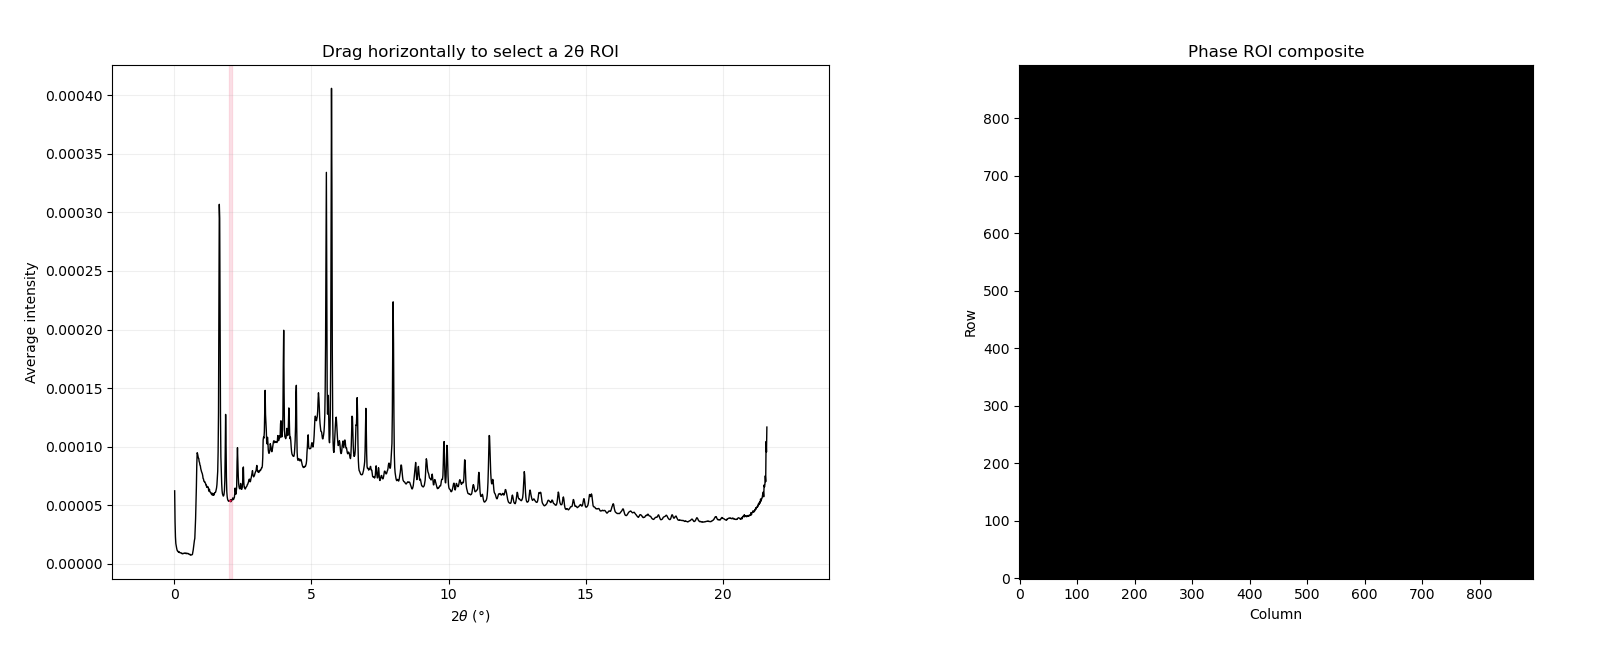

In [14]:
# CELL 6 — Define multiple phase ROIs from the average 1D pattern
# Each phase is added one by one.
# Maps contain raw summed intensity or positive net intensity.
# Black background; no independent phase normalization.

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import h5py

from matplotlib.widgets import SpanSelector
from matplotlib.lines import Line2D
from IPython.display import display
from ipywidgets import (
    FloatText,
    Checkbox,
    Text,
    ColorPicker,
    Button,
    HTML,
    HBox,
    VBox,
    Layout,
)

plt.close("all")

# ==============================================================
# 1. Basic data information
# ==============================================================

x = np.asarray(x, dtype=np.float64).squeeze()
n_theta = len(x)

if x.ndim != 1:
    raise ValueError("x must be a one-dimensional 2θ array.")

if not np.all(np.diff(x) > 0):
    raise ValueError("x must be sorted in increasing 2θ order.")

tth_min = float(x[0])
tth_max = float(x[-1])

if n_theta > 1:
    tth_step = float(np.min(np.abs(np.diff(x))))
else:
    tth_step = 0.01

# Saved phase definitions and raw maps
phases = []

# ==============================================================
# 2. Read average diffraction pattern efficiently
# ==============================================================

def read_average_pattern():

    average = np.zeros(n_theta, dtype=np.float64)

    with h5py.File(scan_path, "r") as f:

        dset = f[recon_path]

        for start in range(0, n_theta, THETA_CHUNK):

            stop = min(start + THETA_CHUNK, n_theta)

            block = np.asarray(
                dset[start:stop, :, :],
                dtype=np.float32,
            )

            average[start:stop] = np.nanmean(
                block,
                axis=(1, 2),
            )

    return average


average_pattern = read_average_pattern()

# ==============================================================
# 3. Controls for the next phase
# ==============================================================

phase_name_box = Text(
    value="Phase 1",
    description="Name:",
    layout=Layout(width="230px"),
)

phase_color_picker = ColorPicker(
    value="#e6194b",
    description="Color:",
    layout=Layout(width="220px"),
)

roi_min_box = FloatText(
    value=max(tth_min, 2.0),
    description="2θ min:",
    layout=Layout(width="190px"),
)

roi_max_box = FloatText(
    value=min(tth_max, 2.1),
    description="2θ max:",
    layout=Layout(width="190px"),
)

net_checkbox = Checkbox(
    value=True,
    description="Use net intensity above endpoint background",
    indent=False,
    layout=Layout(width="360px"),
)

log_checkbox = Checkbox(
    value=False,
    description="Log scale for 1D pattern",
    indent=False,
)

add_button = Button(
    description="Add phase",
    button_style="success",
    icon="plus",
    layout=Layout(width="135px"),
)

remove_button = Button(
    description="Remove last",
    icon="minus",
    layout=Layout(width="135px"),
)

clear_button = Button(
    description="Clear phases",
    button_style="warning",
    icon="trash",
    layout=Layout(width="135px"),
)

status = HTML()
phase_list = HTML()

# ==============================================================
# 4. Figure
# ==============================================================

fig, (ax_pattern, ax_map) = plt.subplots(
    1,
    2,
    figsize=(16, 6.5),
    gridspec_kw={"width_ratios": [1.3, 1]},
)

# Average 1D pattern
ax_pattern.plot(
    x,
    average_pattern,
    color="black",
    linewidth=1,
)

ax_pattern.set_title("Drag horizontally to select a 2θ ROI")
ax_pattern.set_xlabel(r"$2\theta$ (°)")
ax_pattern.set_ylabel("Average intensity")
ax_pattern.grid(alpha=0.2)

# Empty RGB phase map
phase_image = ax_map.imshow(
    np.zeros((n_rows, n_cols, 3), dtype=np.float32),
    origin="lower",
    aspect="equal",
    interpolation="nearest",
)

ax_map.set_facecolor("black")
ax_map.set_title("Phase ROI composite")
ax_map.set_xlabel("Column")
ax_map.set_ylabel("Row")

fig.subplots_adjust(
    left=0.07,
    right=0.97,
    bottom=0.11,
    top=0.90,
    wspace=0.27,
)

saved_pattern_artists = []
preview_artists = []

# ==============================================================
# 5. Convert 2θ limits to indices
# ==============================================================

def theta_indices(t0, t1):

    t0, t1 = sorted((float(t0), float(t1)))

    t0 = max(tth_min, t0)
    t1 = min(tth_max, t1)

    i0 = int(np.searchsorted(x, t0, side="left"))
    i1 = int(np.searchsorted(x, t1, side="right"))

    i0 = max(0, min(i0, n_theta - 1))
    i1 = max(i0 + 1, min(i1, n_theta))

    return i0, i1

# ==============================================================
# 6. Read raw or net ROI map directly from disk
# ==============================================================

def read_roi_map(i0, i1, subtract_background=False):
    """
    Raw mode
    --------
    Sum measured counts inside the selected 2θ ROI.

    Net mode
    --------
    At every scanning point:

    1. Join the first and last ROI values with a straight line.
    2. Subtract the line from the measured pattern.
    3. Keep only intensity above the line.
    4. Sum the remaining positive intensity.

    The returned map is not normalized.
    """

    roi_map = np.zeros(
        (n_rows, n_cols),
        dtype=np.float32,
    )

    with h5py.File(scan_path, "r") as f:

        dset = f[recon_path]

        # ------------------------------------------------------
        # Raw summed intensity
        # ------------------------------------------------------

        if not subtract_background:

            for start in range(i0, i1, THETA_CHUNK):

                stop = min(start + THETA_CHUNK, i1)

                block = np.asarray(
                    dset[start:stop, :, :],
                    dtype=np.float32,
                )

                roi_map += np.nansum(
                    block,
                    axis=0,
                    dtype=np.float32,
                )

        # ------------------------------------------------------
        # Positive intensity above linear background
        # ------------------------------------------------------

        else:

            if (i1 - i0) < 3:
                return roi_map

            first = np.asarray(
                dset[i0, :, :],
                dtype=np.float32,
            )

            last = np.asarray(
                dset[i1 - 1, :, :],
                dtype=np.float32,
            )

            x0 = float(x[i0])
            x1 = float(x[i1 - 1])

            if x1 == x0:
                return roi_map

            difference = last - first

            for start in range(i0, i1, THETA_CHUNK):

                stop = min(start + THETA_CHUNK, i1)

                block = np.asarray(
                    dset[start:stop, :, :],
                    dtype=np.float32,
                )

                fraction = (
                    (x[start:stop] - x0) / (x1 - x0)
                ).astype(np.float32)

                background = (
                    first[None, :, :]
                    + fraction[:, None, None]
                    * difference[None, :, :]
                )

                residual = block - background

                # Keep only intensity above the background line
                np.maximum(
                    residual,
                    0,
                    out=residual,
                )

                roi_map += np.nansum(
                    residual,
                    axis=0,
                    dtype=np.float32,
                )

    roi_map = np.nan_to_num(
        roi_map,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return roi_map

# ==============================================================
# 7. Current ROI preview on the average pattern
# ==============================================================

def clear_artists(artists):

    for artist in artists:

        try:
            artist.remove()
        except ValueError:
            pass

    artists.clear()


def draw_current_preview(_=None):

    clear_artists(preview_artists)

    t0, t1 = sorted(
        (roi_min_box.value, roi_max_box.value)
    )

    t0 = max(tth_min, t0)
    t1 = min(tth_max, t1)

    if t1 <= t0:
        fig.canvas.draw_idle()
        return

    color = phase_color_picker.value
    i0, i1 = theta_indices(t0, t1)

    span = ax_pattern.axvspan(
        t0,
        t1,
        color=color,
        alpha=0.12,
    )

    preview_artists.append(span)

    if net_checkbox.value and (i1 - i0) >= 3:

        line, = ax_pattern.plot(
            [x[i0], x[i1 - 1]],
            [average_pattern[i0], average_pattern[i1 - 1]],
            color=color,
            linestyle="--",
            linewidth=1.5,
        )

        preview_artists.append(line)

    fig.canvas.draw_idle()

# ==============================================================
# 8. Draw saved ROIs on average pattern
# ==============================================================

def redraw_saved_rois():

    clear_artists(saved_pattern_artists)

    legend_handles = []

    for phase in phases:

        t0 = phase["t0"]
        t1 = phase["t1"]
        i0 = phase["i0"]
        i1 = phase["i1"]
        color = phase["color"]

        span = ax_pattern.axvspan(
            t0,
            t1,
            color=color,
            alpha=0.22,
        )

        saved_pattern_artists.append(span)

        if phase["net"] and (i1 - i0) >= 3:

            line, = ax_pattern.plot(
                [x[i0], x[i1 - 1]],
                [average_pattern[i0], average_pattern[i1 - 1]],
                color=color,
                linestyle="--",
                linewidth=2,
            )

            saved_pattern_artists.append(line)

        mode = "net" if phase["net"] else "raw"

        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="s",
                linestyle="",
                markerfacecolor=color,
                markeredgecolor="black",
                markersize=8,
                label=(
                    f'{phase["name"]}: '
                    f'{t0:.4f}–{t1:.4f}° ({mode})'
                ),
            )
        )

    old_legend = ax_pattern.get_legend()

    if old_legend is not None:
        old_legend.remove()

    if legend_handles:

        ax_pattern.legend(
            handles=legend_handles,
            loc="best",
            fontsize=8,
        )

# ==============================================================
# 9. Draw composite map
# ==============================================================

def redraw_phase_map():

    rgb_sum = np.zeros(
        (n_rows, n_cols, 3),
        dtype=np.float32,
    )

    total_intensity = np.zeros(
        (n_rows, n_cols),
        dtype=np.float32,
    )

    map_legend = []

    for phase in phases:

        raw_map = phase["map"]
        color = phase["color"]

        rgb = np.asarray(
            mcolors.to_rgb(color),
            dtype=np.float32,
        )

        # Raw intensity is used directly.
        rgb_sum += raw_map[..., None] * rgb[None, None, :]
        total_intensity += raw_map

        map_legend.append(
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=color,
                markeredgecolor="white",
                markersize=8,
                label=phase["name"],
            )
        )

    # One common linear display scale for the entire composite.
    # There is no separate normalization for each phase.
    if phases:

        common_scale = float(np.nanmax(total_intensity))

        if not np.isfinite(common_scale) or common_scale <= 0:
            common_scale = 1.0

        image = rgb_sum / common_scale

    else:

        common_scale = 1.0
        image = rgb_sum

    phase_image.set_data(
        np.clip(image, 0.0, 1.0)
    )

    old_legend = ax_map.get_legend()

    if old_legend is not None:
        old_legend.remove()

    if map_legend:

        ax_map.legend(
            handles=map_legend,
            loc="upper left",
            bbox_to_anchor=(1.01, 1),
            fontsize=8,
        )

    ax_map.set_title(
        "Phase ROI composite\n"
        f"common raw-intensity scale: 0–{common_scale:.4g}"
    )

    fig.canvas.draw_idle()

# ==============================================================
# 10. Phase list
# ==============================================================

def update_phase_list():

    if not phases:

        phase_list.value = "<b>No phases added.</b>"
        return

    entries = []

    for i, phase in enumerate(phases, start=1):

        mode = "net" if phase["net"] else "raw"

        entries.append(
            f'<span style="color:{phase["color"]};">■</span> '
            f'{i}. {phase["name"]}: '
            f'{phase["t0"]:.4f}–{phase["t1"]:.4f}° '
            f'({mode})'
        )

    phase_list.value = "<br>".join(entries)

# ==============================================================
# 11. Add, remove and clear phases
# ==============================================================

def add_phase(_=None):

    t0, t1 = sorted(
        (roi_min_box.value, roi_max_box.value)
    )

    t0 = max(tth_min, float(t0))
    t1 = min(tth_max, float(t1))

    if t1 <= t0:

        status.value = (
            '<span style="color:red;">'
            "Select a valid 2θ interval."
            "</span>"
        )

        return

    i0, i1 = theta_indices(t0, t1)

    if net_checkbox.value and (i1 - i0) < 3:

        status.value = (
            '<span style="color:red;">'
            "Net intensity requires at least three 2θ points."
            "</span>"
        )

        return

    status.value = "<i>Reading ROI map...</i>"

    raw_map = read_roi_map(
        i0,
        i1,
        subtract_background=net_checkbox.value,
    )

    phases.append(
        {
            "name": phase_name_box.value.strip()
                    or f"Phase {len(phases) + 1}",
            "color": phase_color_picker.value,
            "t0": t0,
            "t1": t1,
            "i0": i0,
            "i1": i1,
            "net": bool(net_checkbox.value),
            "map": raw_map,
        }
    )

    status.value = (
        '<span style="color:green;">'
        f'Added {phases[-1]["name"]}.'
        "</span>"
    )

    clear_artists(preview_artists)

    redraw_saved_rois()
    redraw_phase_map()
    update_phase_list()

    phase_name_box.value = f"Phase {len(phases) + 1}"


def remove_last_phase(_=None):

    if phases:

        removed = phases.pop()

        status.value = (
            f'Removed <b>{removed["name"]}</b>.'
        )

    redraw_saved_rois()
    redraw_phase_map()
    update_phase_list()


def clear_phases(_=None):

    phases.clear()

    status.value = "All phases cleared."

    redraw_saved_rois()
    redraw_phase_map()
    update_phase_list()
    draw_current_preview()

# ==============================================================
# 12. Select ROI by dragging on average pattern
# ==============================================================

def on_span_select(t0, t1):

    if abs(t1 - t0) < tth_step:
        return

    t0, t1 = sorted((t0, t1))

    roi_min_box.value = max(tth_min, float(t0))
    roi_max_box.value = min(tth_max, float(t1))

    draw_current_preview()


span_selector = SpanSelector(
    ax_pattern,
    on_span_select,
    direction="horizontal",
    useblit=True,
    props={
        "facecolor": "gray",
        "alpha": 0.12,
    },
    interactive=True,
    drag_from_anywhere=True,
)

# ==============================================================
# 13. Connect controls
# ==============================================================

add_button.on_click(add_phase)
remove_button.on_click(remove_last_phase)
clear_button.on_click(clear_phases)

roi_min_box.observe(
    draw_current_preview,
    names="value",
)

roi_max_box.observe(
    draw_current_preview,
    names="value",
)

phase_color_picker.observe(
    draw_current_preview,
    names="value",
)

net_checkbox.observe(
    draw_current_preview,
    names="value",
)


def update_log_scale(change):

    ax_pattern.set_yscale(
        "log" if log_checkbox.value else "linear"
    )

    fig.canvas.draw_idle()


log_checkbox.observe(
    update_log_scale,
    names="value",
)

# ==============================================================
# 14. Display
# ==============================================================

controls = VBox(
    [
        HBox([phase_name_box, phase_color_picker]),
        HBox([roi_min_box, roi_max_box]),
        HBox([net_checkbox, log_checkbox]),
        HBox([add_button, remove_button, clear_button]),
        status,
        phase_list,
    ],
    layout=Layout(width="900px"),
)

display(controls)

update_phase_list()
draw_current_preview()

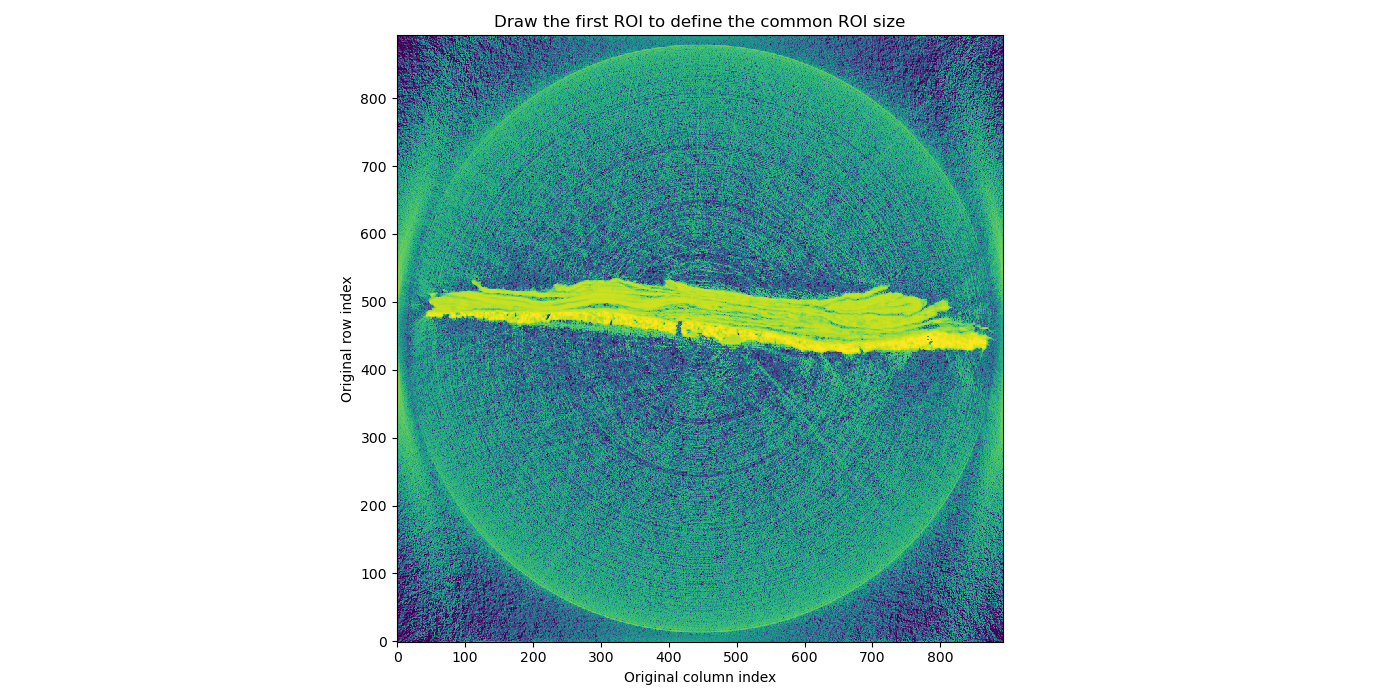

In [9]:
# CELL 7 — Select equal-size, even-dimension ROIs
# The first ROI defines the common ROI shape.
# All later ROIs automatically use the same height and width.
#
# Assumes these are already defined/imported:
# total_intensity_map, norm, x, scan_path, recon_path, THETA_CHUNK
# np, plt, h5py, RectangleSelector, Rectangle
# display, ToggleButtons, Text, Button, HTML, HBox, VBox, Layout

%matplotlib widget

from pathlib import Path

plt.close("all")

n_rows, n_cols = total_intensity_map.shape
n_theta = len(x)

spatial_rois = []

# Set after drawing the first ROI:
# fixed_roi_shape = (height, width)
fixed_roi_shape = None

ROI_COLORS = [
    "red",
    "cyan",
    "magenta",
    "yellow",
    "lime",
    "orange",
]

# ==============================================================
# 1. Controls
# ==============================================================

mode_toggle = ToggleButtons(
    options=[
        ("Zoom / pan", "zoom"),
        ("Draw ROI", "draw"),
    ],
    value="zoom",
    description="Mode:",
)

roi_name_box = Text(
    value="ROI_1",
    description="ROI name:",
    layout=Layout(width="250px"),
)

save_folder_box = Text(
    value=str(Path.cwd() / "saved_rois"),
    description="Save folder:",
    layout=Layout(width="650px"),
)

file_prefix_box = Text(
    value="scan",
    description="Prefix:",
    layout=Layout(width="250px"),
)

remove_button = Button(
    description="Remove last",
    icon="minus",
)

clear_button = Button(
    description="Clear ROIs",
    button_style="warning",
    icon="trash",
)

reset_zoom_button = Button(
    description="Reset zoom",
    icon="home",
)

save_button = Button(
    description="Save all ROIs",
    button_style="success",
    icon="save",
)

roi_list = HTML()
shape_info = HTML()
status = HTML()

# ==============================================================
# 2. Total-intensity figure
# ==============================================================

fig_roi, ax_roi = plt.subplots(figsize=(14, 7))

ax_roi.imshow(
    total_intensity_map,
    norm=norm,
    cmap="viridis",
    origin="lower",
    aspect="equal",
    interpolation="nearest",
)

ax_roi.set_title(
    "Draw the first ROI to define the common ROI size"
)

ax_roi.set_xlabel("Original column index")
ax_roi.set_ylabel("Original row index")

fig_roi.tight_layout()

full_xlim = ax_roi.get_xlim()
full_ylim = ax_roi.get_ylim()

# ==============================================================
# 3. ROI geometry helpers
# ==============================================================

def make_even_size(value0, value1, maximum_size):
    """
    Convert a drawn distance to an even number of pixels.
    Odd sizes are rounded up to the next even value.
    """

    size = max(
        2,
        int(np.ceil(abs(value1 - value0))),
    )

    if size % 2 != 0:
        size += 1

    # Largest possible even size inside the image
    maximum_even = (
        maximum_size
        if maximum_size % 2 == 0
        else maximum_size - 1
    )

    return min(size, maximum_even)


def centered_bounds(center, size, maximum_size):
    """
    Produce inclusive bounds with an exact fixed size,
    shifting the ROI when it reaches an image boundary.
    """

    start = int(
        np.floor(center - size / 2)
    )

    start = max(
        0,
        min(start, maximum_size - size),
    )

    end = start + size - 1

    return int(start), int(end)


def get_pixel_bounds(x0, x1, y0, y1):
    """
    First ROI:
        Defines an even height and width.

    Later ROIs:
        Use exactly the same height and width as the first ROI.
    """

    global fixed_roi_shape

    if None in (x0, x1, y0, y1):
        return None

    column_center = (x0 + x1) / 2
    row_center = (y0 + y1) / 2

    if fixed_roi_shape is None:

        roi_width = make_even_size(
            x0,
            x1,
            n_cols,
        )

        roi_height = make_even_size(
            y0,
            y1,
            n_rows,
        )

        fixed_roi_shape = (
            roi_height,
            roi_width,
        )

    else:

        roi_height, roi_width = fixed_roi_shape

    c0, c1 = centered_bounds(
        column_center,
        roi_width,
        n_cols,
    )

    r0, r1 = centered_bounds(
        row_center,
        roi_height,
        n_rows,
    )

    return r0, r1, c0, c1

# ==============================================================
# 4. Update information displays
# ==============================================================

def update_shape_info():

    if fixed_roi_shape is None:

        shape_info.value = (
            "<b>Common ROI shape:</b> not defined"
        )

    else:

        height, width = fixed_roi_shape

        shape_info.value = (
            f"<b>Locked ROI shape:</b> "
            f"{height} rows × {width} columns "
            f"(both even)"
        )


def update_roi_list():

    if not spatial_rois:

        roi_list.value = "<b>No ROI defined.</b>"
        return

    lines = []

    for roi_number, roi in enumerate(
        spatial_rois,
        start=1,
    ):

        height = roi["r1"] - roi["r0"] + 1
        width = roi["c1"] - roi["c0"] + 1

        lines.append(
            f'<span style="color:{roi["color"]};">■</span> '
            f'<b>{roi_number}. {roi["name"]}</b>: '
            f'original rows {roi["r0"]}–{roi["r1"]}, '
            f'original columns {roi["c0"]}–{roi["c1"]}; '
            f'new rows 0–{height - 1}, '
            f'new columns 0–{width - 1}; '
            f'shape {height} × {width}'
        )

    roi_list.value = "<br>".join(lines)

# ==============================================================
# 5. Add a selected ROI
# ==============================================================

def on_rectangle_select(eclick, erelease):

    if mode_toggle.value != "draw":
        return

    if (
        eclick.inaxes != ax_roi
        or erelease.inaxes != ax_roi
    ):
        return

    first_roi = fixed_roi_shape is None

    bounds = get_pixel_bounds(
        eclick.xdata,
        erelease.xdata,
        eclick.ydata,
        erelease.ydata,
    )

    if bounds is None:
        return

    r0, r1, c0, c1 = bounds

    roi_height = r1 - r0 + 1
    roi_width = c1 - c0 + 1

    # Safety check
    if roi_height % 2 != 0 or roi_width % 2 != 0:

        status.value = (
            '<span style="color:red;">'
            "ROI dimensions are not even."
            "</span>"
        )

        return

    name = roi_name_box.value.strip()

    if not name:
        name = f"ROI_{len(spatial_rois) + 1}"

    color = ROI_COLORS[
        len(spatial_rois) % len(ROI_COLORS)
    ]

    rectangle = Rectangle(
        (c0 - 0.5, r0 - 0.5),
        roi_width,
        roi_height,
        fill=False,
        edgecolor=color,
        linewidth=2,
    )

    ax_roi.add_patch(rectangle)

    label = ax_roi.text(
        c0,
        r1 + 0.7,
        name,
        color=color,
        fontsize=10,
        fontweight="bold",
        bbox={
            "facecolor": "black",
            "alpha": 0.6,
            "edgecolor": "none",
        },
    )

    spatial_rois.append(
        {
            "roi_number": len(spatial_rois) + 1,
            "name": name,
            "color": color,
            "r0": r0,
            "r1": r1,
            "c0": c0,
            "c1": c1,
            "rectangle": rectangle,
            "label": label,
        }
    )

    roi_name_box.value = (
        f"ROI_{len(spatial_rois) + 1}"
    )

    if first_roi:

        status.value = (
            '<span style="color:green;">'
            f"Added {name}. Common shape locked to "
            f"{roi_height} × {roi_width} pixels."
            "</span>"
        )

        ax_roi.set_title(
            "Common ROI shape locked — draw more ROI centres"
        )

    else:

        status.value = (
            '<span style="color:green;">'
            f"Added {name} with the fixed "
            f"{roi_height} × {roi_width} shape."
            "</span>"
        )

    update_shape_info()
    update_roi_list()
    fig_roi.canvas.draw_idle()

# ==============================================================
# 6. Rectangle selector
# ==============================================================

selector = RectangleSelector(
    ax_roi,
    on_rectangle_select,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="data",
    interactive=False,
    props={
        "facecolor": "none",
        "edgecolor": "white",
        "linewidth": 1.5,
        "linestyle": "--",
    },
)

selector.set_active(False)


def change_mode(change):

    selector.set_active(
        change["new"] == "draw"
    )


mode_toggle.observe(
    change_mode,
    names="value",
)

# ==============================================================
# 7. Mouse-wheel zoom
# ==============================================================

def zoom_map(event):

    if event.inaxes != ax_roi:
        return

    if event.xdata is None or event.ydata is None:
        return

    x0, x1 = ax_roi.get_xlim()
    y0, y1 = ax_roi.get_ylim()

    scale = (
        0.8
        if event.button == "up"
        else 1.25
    )

    new_width = (x1 - x0) * scale
    new_height = (y1 - y0) * scale

    x_fraction = (
        (event.xdata - x0)
        / (x1 - x0)
    )

    y_fraction = (
        (event.ydata - y0)
        / (y1 - y0)
    )

    ax_roi.set_xlim(
        event.xdata - new_width * x_fraction,
        event.xdata + new_width * (1 - x_fraction),
    )

    ax_roi.set_ylim(
        event.ydata - new_height * y_fraction,
        event.ydata + new_height * (1 - y_fraction),
    )

    fig_roi.canvas.draw_idle()


fig_roi.canvas.mpl_connect(
    "scroll_event",
    zoom_map,
)

# ==============================================================
# 8. Remove, clear and reset
# ==============================================================

def remove_last_roi(_=None):

    global fixed_roi_shape

    if not spatial_rois:
        return

    roi = spatial_rois.pop()

    roi["rectangle"].remove()
    roi["label"].remove()

    # If no ROI remains, allow a new common shape
    if not spatial_rois:

        fixed_roi_shape = None

        ax_roi.set_title(
            "Draw the first ROI to define the common ROI size"
        )

    roi_name_box.value = (
        f"ROI_{len(spatial_rois) + 1}"
    )

    status.value = (
        f'Removed <b>{roi["name"]}</b>.'
    )

    update_shape_info()
    update_roi_list()
    fig_roi.canvas.draw_idle()


def clear_all_rois(_=None):

    global fixed_roi_shape

    for roi in spatial_rois:

        roi["rectangle"].remove()
        roi["label"].remove()

    spatial_rois.clear()
    fixed_roi_shape = None

    roi_name_box.value = "ROI_1"

    status.value = (
        "All ROIs cleared. Draw a new first ROI "
        "to define another common size."
    )

    ax_roi.set_title(
        "Draw the first ROI to define the common ROI size"
    )

    update_shape_info()
    update_roi_list()
    fig_roi.canvas.draw_idle()


def reset_zoom(_=None):

    ax_roi.set_xlim(full_xlim)
    ax_roi.set_ylim(full_ylim)

    fig_roi.canvas.draw_idle()


remove_button.on_click(remove_last_roi)
clear_button.on_click(clear_all_rois)
reset_zoom_button.on_click(reset_zoom)

# ==============================================================
# 9. File-name helper
# ==============================================================

def safe_name(name):

    cleaned = "".join(
        character
        if character.isalnum()
        or character in "-_"
        else "_"
        for character in name.strip()
    )

    return cleaned.strip("_") or "ROI"

# ==============================================================
# 10. Save all ROI diffraction arrays
# ==============================================================

def save_all_rois(_=None):

    if not spatial_rois:

        status.value = (
            '<span style="color:red;">'
            "Draw at least one ROI first."
            "</span>"
        )

        return

    expected_shape = fixed_roi_shape

    for roi in spatial_rois:

        roi_shape = (
            roi["r1"] - roi["r0"] + 1,
            roi["c1"] - roi["c0"] + 1,
        )

        if roi_shape != expected_shape:

            status.value = (
                '<span style="color:red;">'
                "The ROI shapes are not identical."
                "</span>"
            )

            return

    save_button.disabled = True

    output_folder = Path(
        save_folder_box.value
    ).expanduser()

    output_folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    prefix = safe_name(
        file_prefix_box.value
    )

    saved_names = []

    try:

        with h5py.File(scan_path, "r") as f:

            dset = f[recon_path]

            if dset.shape[0] != n_theta:

                raise ValueError(
                    "The number of 2θ values does not match "
                    "the first dataset dimension."
                )

            for roi_number, roi in enumerate(
                spatial_rois,
                start=1,
            ):

                r0 = roi["r0"]
                r1 = roi["r1"]
                c0 = roi["c0"]
                c1 = roi["c1"]

                roi_height = r1 - r0 + 1
                roi_width = c1 - c0 + 1

                status.value = (
                    f"<i>Saving {roi['name']}...</i>"
                )

                filename = (
                    f"{prefix}_"
                    f"{roi_number:02d}_"
                    f"{safe_name(roi['name'])}.npz"
                )

                output_path = (
                    output_folder / filename
                )

                temporary_path = output_folder / (
                    f".temporary_{roi_number:02d}.npy"
                )

                intensity = np.lib.format.open_memmap(
                    temporary_path,
                    mode="w+",
                    dtype=dset.dtype,
                    shape=(
                        n_theta,
                        roi_height,
                        roi_width,
                    ),
                )

                for start in range(
                    0,
                    n_theta,
                    THETA_CHUNK,
                ):

                    stop = min(
                        start + THETA_CHUNK,
                        n_theta,
                    )

                    intensity[start:stop] = dset[
                        start:stop,
                        r0:r1 + 1,
                        c0:c1 + 1,
                    ]

                intensity.flush()

                # --------------------------------------------------
                # New local indices inside this ROI
                # --------------------------------------------------

                new_row_index = np.arange(
                    roi_height,
                    dtype=np.int32,
                )

                new_col_index = np.arange(
                    roi_width,
                    dtype=np.int32,
                )

                new_row_grid, new_col_grid = np.meshgrid(
                    new_row_index,
                    new_col_index,
                    indexing="ij",
                )

                # --------------------------------------------------
                # Original indices in the complete image
                # --------------------------------------------------

                original_row_index = np.arange(
                    r0,
                    r1 + 1,
                    dtype=np.int32,
                )

                original_col_index = np.arange(
                    c0,
                    c1 + 1,
                    dtype=np.int32,
                )

                original_row_grid, original_col_grid = np.meshgrid(
                    original_row_index,
                    original_col_index,
                    indexing="ij",
                )

                # --------------------------------------------------
                # Complete mapping:
                #
                # last axis:
                # 0 = new row
                # 1 = new column
                # 2 = original row
                # 3 = original column
                # --------------------------------------------------

                index_mapping = np.stack(
                    [
                        new_row_grid,
                        new_col_grid,
                        original_row_grid,
                        original_col_grid,
                    ],
                    axis=-1,
                ).astype(np.int32)

                index_table = index_mapping.reshape(
                    -1,
                    4,
                )

                np.savez(
                    output_path,

                    # Shape:
                    # [two_theta, new_row, new_column]
                    intensity=intensity,

                    two_theta=np.asarray(x),

                    # New ROI indices
                    new_row_index=new_row_index,
                    new_col_index=new_col_index,

                    new_row_grid=new_row_grid,
                    new_col_grid=new_col_grid,

                    # Original scan indices
                    original_row_index=original_row_index,
                    original_col_index=original_col_index,

                    original_row_grid=original_row_grid,
                    original_col_grid=original_col_grid,

                    # Mapping between new and original indices
                    index_mapping=index_mapping,
                    index_table=index_table,

                    index_table_columns=np.array(
                        [
                            "new_row",
                            "new_column",
                            "original_row",
                            "original_column",
                        ]
                    ),

                    total_intensity_roi=total_intensity_map[
                        r0:r1 + 1,
                        c0:c1 + 1,
                    ],

                    roi_number=np.array(
                        roi_number,
                        dtype=np.int32,
                    ),

                    roi_bounds_original=np.array(
                        [r0, r1, c0, c1],
                        dtype=np.int32,
                    ),

                    roi_shape=np.array(
                        [roi_height, roi_width],
                        dtype=np.int32,
                    ),

                    common_roi_shape=np.array(
                        fixed_roi_shape,
                        dtype=np.int32,
                    ),

                    axis_order=np.array(
                        [
                            "two_theta",
                            "new_row",
                            "new_column",
                        ]
                    ),

                    roi_name=np.array(
                        roi["name"]
                    ),

                    source_file=np.array(
                        str(scan_path)
                    ),

                    source_dataset=np.array(
                        str(recon_path)
                    ),
                )

                del intensity

                temporary_path.unlink(
                    missing_ok=True
                )

                saved_names.append(filename)

        status.value = (
            '<span style="color:green;">'
            f"Saved {len(saved_names)} equal-size ROI file(s) in:<br>"
            f"<b>{output_folder}</b><br>"
            + "<br>".join(saved_names)
            + "</span>"
        )

    except Exception as error:

        status.value = (
            '<span style="color:red;">'
            f"Save failed: {error}"
            "</span>"
        )

    finally:

        save_button.disabled = False


save_button.on_click(save_all_rois)

# ==============================================================
# 11. Display controls
# ==============================================================

controls = VBox(
    [
        HBox(
            [
                mode_toggle,
                roi_name_box,
                reset_zoom_button,
            ]
        ),
        HBox(
            [
                remove_button,
                clear_button,
            ]
        ),
        shape_info,
        save_folder_box,
        HBox(
            [
                file_prefix_box,
                save_button,
            ]
        ),
        roi_list,
        status,
    ],
    layout=Layout(width="950px"),
)

display(controls)

update_shape_info()
update_roi_list()